# **COMP 2211 Introduction to Artificial Intelligence** #
# Programming Assignment 2 - I'm Not a Robot #

<img src="https://i.imgur.com/Qpxe4ma.png" alt="captcha" height="400">

In [80]:
# classic imports, oc iknow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 # opencv

# system imports
import os
import zipfile

# keras/sklearn imports
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# global constant
IMG_SIZE = 64 # don't change

# Introduction and Preparing the Dataset
In this programming assignment, you will build a CNN and an autoencoder (a special form of CNN) to pass the CAPTCHA test using Pokemon images. Follow the instructions in the notebook to complete the 7 tasks. Please use Google Colab for this assignment to ensure library compatibility with ZINC.

## About the Dataset
For this assignment, we will use a Pokemon images dataset from Keras. The original dataset consists of 143 Pokemon, each with 50 to 200 images. Note that the TAs have provided a smaller sample of this dataset to create hidden test cases, which will be used for grading.

You can visualize the dataset by running the following 2 cells. Before doing so, upload the `Pokemon-images.zip` file to Google Colab by navigating to the Files section on the left. Please be aware that files uploaded to Colab are not permanent; once your runtime disconnects, you will need to re-upload the files to continue working.

In [81]:
if __name__ == '__main__':
    import os
    zip_file_path = './Pokemon-images.zip'
    image_dir = './images/'

    # Unzip the dataset
    os.makedirs(image_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(image_dir)

    # Read all image files and group them by pokemon name
    files = [f for f in os.listdir(image_dir)]
    pokemon_images = {}
    for f in files:
        pokemon_name = f.split('_', 1)[0]
        if pokemon_name in pokemon_images:
            pokemon_images[pokemon_name].append(f)
        else:
            pokemon_images[pokemon_name] = [f]

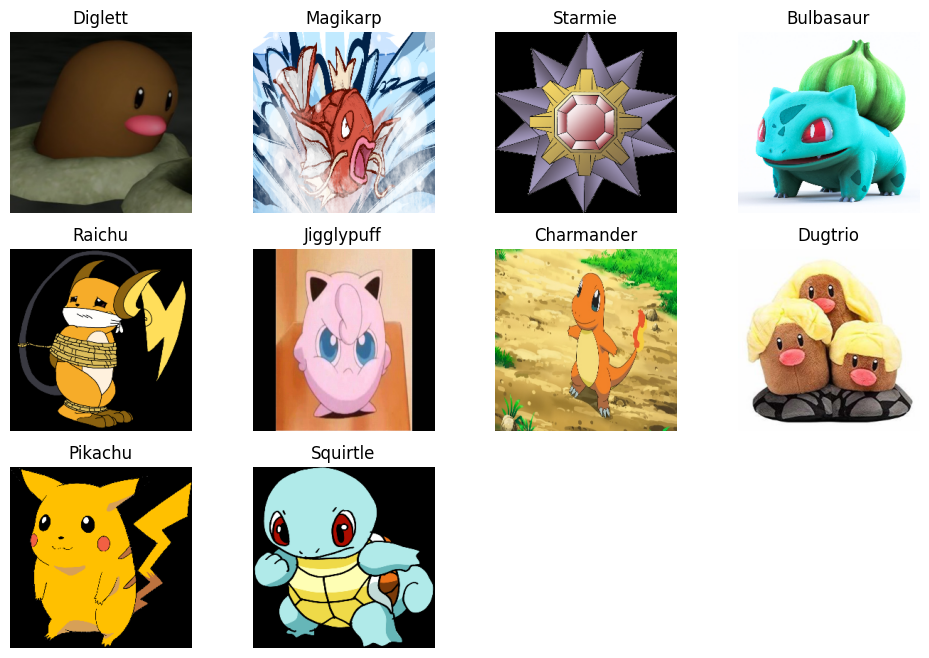

In [82]:
# Plot a sample image for each pokemon in a single figure
if __name__ == '__main__':
    plt.figure(figsize=(12, 8))
    for i, (pokemon, images) in enumerate(pokemon_images.items()):
        img_path = os.path.join(image_dir, images[0])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.title(pokemon)
        plt.axis('off')

In [83]:
# Print the number of images for each Pokémon
if __name__ == '__main__':
    for pokemon, images in pokemon_images.items():
        print(f'{pokemon}: {len(images)} images')

Diglett: 200 images
Magikarp: 200 images
Starmie: 200 images
Bulbasaur: 200 images
Raichu: 200 images
Jigglypuff: 200 images
Charmander: 200 images
Dugtrio: 200 images
Pikachu: 200 images
Squirtle: 200 images


# Data Augmentation
There is a data imbalance issue, and the dataset is relatively small. So, in this section, we will augment the data. You will need to use the `cv2` (OpenCV) library to complete 3 functions for augmentation.

Write code in the cell below to comeplete tasks 1 and 2.

**Task 1**: Complete the `translate_image()` function.

**Task 2**: Complete the `rotate_image()` function.

You may find the following documentation useful:
- [cv2.warpAffine](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html#ga0203d9ee5fcd28d40dbc4a1ea4451983)
- [cv2.getRotationMatrix2D](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html#gafbbc470ce83812914a70abfb604f4326)

In [84]:
# Image translation using opencv
def translate_image(image, tx, ty):
    # TODO (Task 1): Complete the function to translate image (downwards by ty pixels and rightwards by tx pixels)
    # Hint: Use cv2.warpAffine and create the transformation matrix M
    h, w = image.shape[:2]
    
    # Create translation matrix (M is 2x3 float array)
    M = np.float32([[1, 0, tx],   # shift x (right +)
                    [0, 1, ty]])  # shift y (down +)
    
    # Apply affine warp (keep original size)
    translated_img = cv2.warpAffine(image, M, (w, h))
    
    return translated_img
    
    # return image

# Image rotation using opencv
def rotate_image(image, angle):
    # TODO (Task 2): Complete the function to rotate image for the given angle (in the anticlockwise direction)
    # Hint: Use cv2.getRotationMatrix2D and cv2.warpAffine

    # height and width
    h, w = image.shape[:2]
    
    # center of the image
    center = (w // 2, h // 2)
    
    # Create rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, scale=1.0)
    
    # apply rotation 
    rotated_img = cv2.warpAffine(image, M, (w, h))

    # trial: rotated_img = cv2.warpAffine(image, M, )
    
    return rotated_img

    # return image

Color Jittering is a data augmentation technique used to generate new images by modifying contrast, brightness, and saturation (note: hue is not included in this assignment).
- Contrast: Changes the degree of difference between the darkest and lightest parts of an image by scaling all pixel values.
- Brightness: Makes the image lighter or darker by applying a linear shift to all pixel values.
- Saturation: Adjusts how far RGB values are from the "gray" center. Because this is complex to perform directly in the RGB color space, we suggest first converting the image to the HSV model and then scaling the S (Saturation) channel.

Write code in the cell below to comeplete task 3. You may find the following documentation useful:
- [cv2.convertScaleAbs](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga3460e9c9f37b563ab9dd550c4d8c4e7d)
- [cv2.cvtColor](https://docs.opencv.org/4.x/d8/d01/group__imgproc__color__conversions.html#gaf86c09fe702ed037c03c2bc603ceab14)

**Task 3**: Complete the `color_jitter()` function.

In [85]:
# Color jittering using opencv
def color_jitter(image, c_factor=None, b_factor=None, s_factor=None):
    # TODO (Task 3): Complete the function to apply color jittering
    # c_factor: contrast factor
    # b_factor: brightness factor
    # s_factor: saturation factor
    # You can assume the range of each channel is [0, 255] and only one factor is not None at a time

    img = image.copy()

    #  Adjust CONTRAST
    if c_factor is not None:
        # alpha = contrast factor, beta = brightness (0 for just contrast)
        img = cv2.convertScaleAbs(img, alpha=c_factor, beta=0)

    #  or Adjust BRIGHTNESS 
    elif b_factor is not None:
        # alpha=1 (no contrast change), beta = brightness shift
        img = cv2.convertScaleAbs(img, alpha=1.0, beta=b_factor)

    #  or Adjust SATURATION 
    elif s_factor is not None:
        hsv = cv2.cvtColor(img, cv2.rgb)
        
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)


        hsv[:, :, 1] = cv2.convertScaleAbs(hsv[:, :, 1], alpha=s_factor, beta=0)

        # 转回去
        img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


    return img

    # return image

After implementing the augmentation operations, we can visualize the augmented images.

In [86]:
# Visualize the augmentations
def augment_and_display(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    translated_img = translate_image(img, tx=30, ty=50)
    rotated_img = rotate_image(img, angle=45)
    jittered_img_c = color_jitter(img, c_factor=1.5)
    jittered_img_b = color_jitter(img, b_factor=30)
    jittered_img_s = color_jitter(img, s_factor=1.5)

    plt.figure(figsize=(12, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(translated_img)
    plt.title('Translated Image')
    plt.axis('off')
    plt.subplot(2, 3, 3)
    plt.imshow(rotated_img)
    plt.title('Rotated Image')
    plt.axis('off')
    plt.subplot(2, 3, 4)
    plt.imshow(jittered_img_c)
    plt.title('Color Jittered Image (Contrast)')
    plt.axis('off')
    plt.subplot(2, 3, 5)
    plt.imshow(jittered_img_b)
    plt.title('Color Jittered Image (Brightness)')
    plt.axis('off')
    plt.subplot(2, 3, 6)
    plt.imshow(jittered_img_s)
    plt.title('Color Jittered Image (Saturation)')
    plt.axis('off')
    plt.show()

if __name__ == '__main__':
    sample_image_path = os.path.join(image_dir, pokemon_images['Bulbasaur'][0])
    augment_and_display(sample_image_path)

AttributeError: module 'cv2' has no attribute 'rgb'

Next, we will augment our data. Feel free to adjust the augmentation parameters and the number of augmented images as needed.

In [ ]:
# Augment data until each pokemon has at least TARGET_COUNT images
if __name__ == '__main__':
    TARGET_COUNT = 200
    for pokemon, images in pokemon_images.items():
        current_count = len(images)
        idx = 0
        while current_count < TARGET_COUNT:
            img_path = os.path.join(image_dir, images[idx % len(images)])
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Apply random augmentation
            tx = np.random.randint(-20, 20)
            ty = np.random.randint(-20, 20)
            angle = np.random.randint(-30, 30)
            c_factor = np.random.uniform(0.8, 1.2)
            b_factor = np.random.randint(-20, 20)
            s_factor = np.random.uniform(0.8, 1.2)

            augmented_img = translate_image(img, tx, ty)
            augmented_img = rotate_image(augmented_img, angle)
            augmented_img = color_jitter(augmented_img, c_factor, b_factor, s_factor)

            new_image_name = f"{pokemon}_aug_{current_count}.png"
            new_image_path = os.path.join(image_dir, new_image_name)
            cv2.imwrite(new_image_path, cv2.cvtColor(augmented_img, cv2.COLOR_RGB2BGR))

            images.append(new_image_name)
            current_count += 1
            idx += 1

# Image Classification

In this section, we will use the augmented images to train a CNN model to predict the Pokemon class of an input image. First, we will prepare the data:
- `X` stores each image as a numpy array with the shape (IMG_SIZE, IMG_SIZE, 3).
- `y` contains the one-hot encoded labels.

Then split them into training and testing dataset.

In [ ]:
# Prepare the dataset for image classification training
if __name__ == '__main__':
    # Don't change the code in this cell, especially the pokemon_label_list. The order of labels matters.
    pokemon_label_list = ['Bulbasaur', 'Charmander', 'Diglett', 'Dugtrio', 'Jigglypuff', 'Magikarp', 'Pikachu', 'Raichu', 'Squirtle', 'Starmie']
    files = [f for f in os.listdir(image_dir)]
    X = []
    y = []
    for f in files:
        pokemon_name = f.split('_', 1)[0]
        if pokemon_name in pokemon_label_list:
            img_path = os.path.join(image_dir, f)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # resize to 64x64
            img = img / 255.0  # normalize to [0, 1]
            X.append(img)
            y.append(pokemon_label_list.index(pokemon_name))
    X = np.array(X)
    y = np.array(y)
    y = y.reshape(-1, 1)
    encoder = OneHotEncoder()
    y = encoder.fit_transform(y).toarray()

    print(f"shape of X: {X.shape}")
    print(f"shape of y: {y.shape}")
    print(y)

shape of X: (2000, 64, 64, 3)
shape of y: (2000, 10)
[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]


In [ ]:
# Split the dataset into training and testing sets
if __name__ == '__main__':
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"shape of X_train: {X_train.shape}")
    print(f"shape of X_test: {X_test.shape}")
    print(f"shape of y_train: {y_train.shape}")
    print(f"shape of y_test: {y_test.shape}")  

shape of X_train: (1600, 64, 64, 3)
shape of X_test: (400, 64, 64, 3)
shape of y_train: (1600, 10)
shape of y_test: (400, 10)


Now, it is finally time to build and train your CNN model architecture. You have the option to explore different configurations of the CNN model and evaluate its performance. However, you may only use the following 5 layers:
1. `Conv2D`: You are free to explore kernel configurations, activations, etc. [Doc.](https://keras.io/api/layers/convolution_layers/convolution2d/)
2. `MaxPooling2D`: You are free to explore the pooling size, stride, etc. [Doc.](https://keras.io/api/layers/pooling_layers/max_pooling2d/)
3. `Flatten`: Use this layer to flatten the neurons. [Doc.](https://keras.io/api/layers/reshaping_layers/flatten/)
4. `Dense`: You are free to explore the number of filters, activation functions, etc. [Doc.](https://keras.io/api/layers/core_layers/dense/)
5. `Dropout`: Choose your parameter to prevent overfitting.[Doc.](https://keras.io/api/layers/regularization_layers/dropout/)

Your model should contain at least one layer from each of the mentioned types, except for `Dropout`. The last layer should be a dense layer with 10 neurons, representing the probability of each Pokemon class.

After building your desired architecture, you need to compile the model with following parameters:
1. `optimizer`: An algorithm which updates the model's weight during training to minimize the loss function. You are free to explore different optimizers but we recommend `adam`.
2. `loss`: A mathematical function which measures how far the model's predictions are from actual labels. You are free to choose your own, but we recommend `categorical_crossentropy`.
3. metrics: evaluation measures used to assess the model performance. You are free to choose your own, but we recommend either `f1_score` or `accuracy`.

**Hint:** The model in our solution uses approximately 700,000 trainable parameters. We suggest you keep the number of trainable parameters under 1,000,000 for efficient training and to avoid overfitting.


**Task 4**: Complete the `get_cnn_model()` function

In [ ]:
def get_cnn_model():
    # TODO (Task 4): Complete the CNN model architecture based on the instructions
    model = Sequential()

    # Convolutional Layers + Max Pooling
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten layer (required)
    model.add(Flatten())

    # Dense + Dropout for classification
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    # FINAL LAYER: 10 classes (Pokemon) + softmax
    model.add(Dense(10, activation='softmax'))

    # Compile the model 
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model    # Replace None with the model


if __name__ == '__main__':
    cnn_model = get_cnn_model()
    cnn_model.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
    cnn_model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,722 (4.87 MB)

 Trainable params: 1,275,722 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

It is now time to train the CNN model you built in the previous tasks. You are free to explore different configurations of parameters. However, keep in mind that increasing the number of training epochs requires more computational resources and time, and it does not necessarily indicate better model performance due to the potential for overfitting.

**Task 5**: Train your CNN model.

In [ ]:
if __name__ == '__main__':
    # TODO (Task 5): Train the CNN model. Feel free to change the codes below
    history = cnn_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.2869 - loss: 1.9012 - val_accuracy: 0.4875 - val_loss: 1.3642
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.5944 - loss: 1.1533 - val_accuracy: 0.6925 - val_loss: 0.8768
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7694 - loss: 0.7031 - val_accuracy: 0.8650 - val_loss: 0.4544
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.8338 - loss: 0.5035 - val_accuracy: 0.8975 - val_loss: 0.2936
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8931 - loss: 0.3317 - val_accuracy: 0.9325 - val_loss: 0.2419
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.9050 - loss: 0.2915 - val_accuracy: 0.9125 - val_loss: 0.2843
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9319 - loss: 0.2045 - val_accuracy: 0.9625 - val_loss: 0.1072
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9469 - loss: 0.1596 - val_accuracy: 0.9675 - v

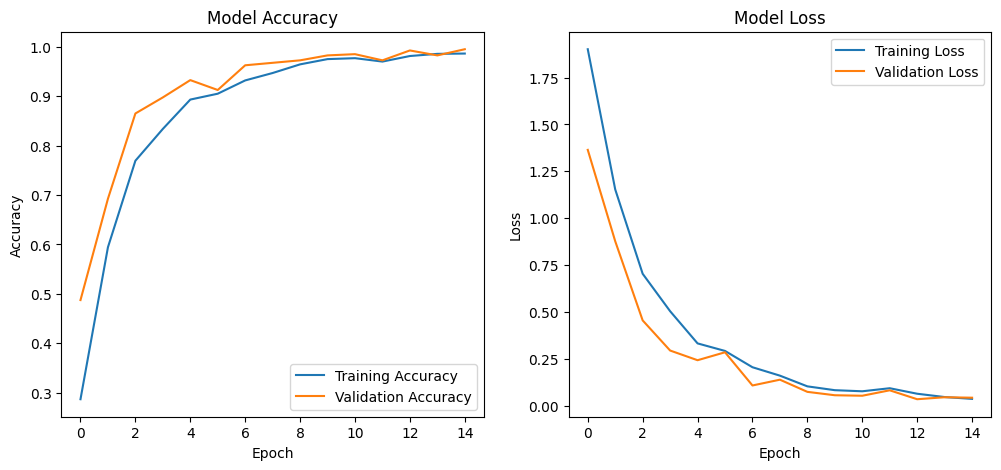

In [ ]:
# Plot your CNN model's training and validation accuracy and loss curves
if __name__ == '__main__':
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

In [ ]:
# Generate and display the confusion matrix
if __name__ == '__main__':
    predictions = cnn_model.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_classes = [pokemon_label_list[i] for i in predicted_classes]
    true_labels = np.argmax(y_test, axis=1)
    true_labels = [pokemon_label_list[i] for i in true_labels]

    confusion_mtx = pd.crosstab(pd.Series(true_labels, name='Actual'), pd.Series(predicted_classes, name='Predicted'))
    print(confusion_mtx)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Predicted   Bulbasaur  Charmander  Diglett  Dugtrio  Jigglypuff  Magikarp  \
Actual                                                                      
Bulbasaur          42           0        0        0           0         0   
Charmander          0          28        0        0           0         0   
Diglett             0           0       31        0           0         0   
Dugtrio             0           0        0       42           0         0   
Jigglypuff          0           0        0        0          38         0   
Magikarp            0           0        0        0           0        46   
Pikachu             0           0        0        0           0         0   
Raichu              0           0        0        0           0         0   
Squirtle            0           0        0        0           0         0   
Starmie             0           0        0        0           0         0   

Predicted   Pikachu  Raichu  Squirt

Just for fun: Run the following cell to see if your model passes the CAPTCHA test.

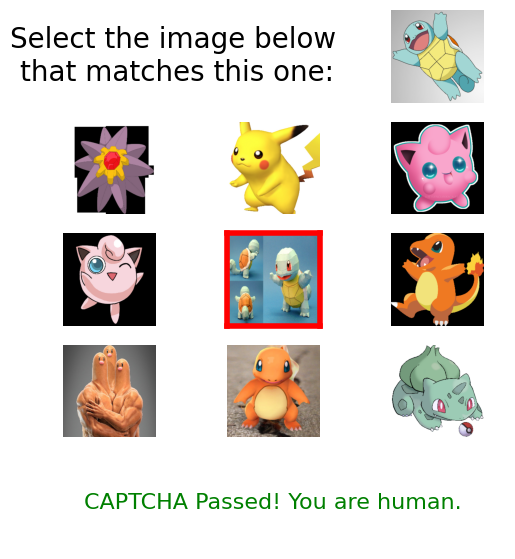

In [ ]:
# A simple CAPTCHA using the trained CNN model
if __name__ == '__main__':
    import random
    random_pokemon = np.random.choice(pokemon_label_list)
    images_of_random_pokemon = [f for f in os.listdir(image_dir) if f.startswith(random_pokemon) and "aug" not in f]
    same_pokemon_images = np.random.choice(images_of_random_pokemon, size=2, replace=False)
    same_pokemon_images = [os.path.join(image_dir, f) for f in same_pokemon_images]

    images_of_other_pokemon = [f for f in os.listdir(image_dir) if not f.startswith(random_pokemon) and "aug" not in f]
    other_images = np.random.choice(images_of_other_pokemon, size=8, replace=False)
    other_images = [os.path.join(image_dir, f) for f in other_images]

    this_image = same_pokemon_images[0]
    below_images = [same_pokemon_images[1]] + other_images
    random.shuffle(below_images)
    this_image_pred = cnn_model.predict(np.array([cv2.resize(cv2.cvtColor(cv2.imread(this_image), cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))]), verbose=0)[0]
    this_image_pred_label = np.argmax(this_image_pred)
    below_image_preds = cnn_model.predict(np.array([cv2.resize(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE)) for img_path in below_images]), verbose=0)
    best_matched_indices = np.argmax(below_image_preds[:, this_image_pred_label])

    plt.figure(figsize=(6,7))

    text = "Select the image below \nthat matches this one:"
    ax1 = plt.subplot(5, 3, 1)
    ax1.text(1.0, 0.5, text, ha='center', va='center', fontsize=20)
    ax1.axis('off')

    plt.subplot(5, 3, 2)
    plt.axis('off')

    plt.subplot(5, 3, 3)
    img = cv2.imread(this_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    for i, img_path in enumerate(below_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(5, 3, i + 4)
        plt.imshow(img)
        plt.axis('off')
        if i == best_matched_indices:
            plt.axis('on')
            plt.gca().spines['top'].set_color('red')
            plt.gca().spines['top'].set_linewidth(4)
            plt.gca().spines['bottom'].set_color('red')
            plt.gca().spines['bottom'].set_linewidth(4)
            plt.gca().spines['left'].set_color('red')
            plt.gca().spines['left'].set_linewidth(4)
            plt.gca().spines['right'].set_color('red')
            plt.gca().spines['right'].set_linewidth(4)
            plt.gca().tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    plt.subplot(5, 3, 13)
    plt.axis('off')
    plt.subplot(5, 3, 15)
    plt.axis('off')

    ax14 = plt.subplot(5, 3, 14)
    ax14.axis('off')
    if best_matched_indices == below_images.index(same_pokemon_images[1]):
        ax14.text(0.5, 0.5, "CAPTCHA Passed! You are human.", ha='center', va='center', fontsize=16, color='green')
    else:
        ax14.text(0.5, 0.5, "CAPTCHA Failed! You are a robot!", ha='center', va='center', fontsize=16, color='red')
    plt.show()

Once you are satisfied with the model's performance, you can run the cell below to save your CNN model. You will need to download this saved model to your local machine for submission.

Additionally, to show that the model is trained by you, ensure that your submitted model has the same structure as the model returned from Task 4.

In [ ]:
if __name__ == '__main__':
  cnn_model.save("cnn_model.keras")

# Image Denoising
After training the CNN, your model can predict any Pokemon images from the ten classes. Or can it? Due to environmental factors or compression artifacts, the input images may contain noise, which can negatively affect your model's performance. This is where image denoising comes in, removing unwanted noise from the images.

In [ ]:
# Function to randomly add gaussian noise and salt-and-pepper noise to the image
def add_noise(normalized_image):
    normalized_image = normalized_image.copy()
    gaussian_noise = np.random.normal(0, 0.05, (IMG_SIZE, IMG_SIZE, 3))
    normalized_image = np.clip(normalized_image + gaussian_noise, 0, 1)

    salt_pepper_prob = 0.08
    rand_matrix = np.random.rand(IMG_SIZE, IMG_SIZE, 3)
    normalized_image[rand_matrix < (salt_pepper_prob / 2)] = 0
    normalized_image[rand_matrix > (1 - salt_pepper_prob / 2)] = 1

    return normalized_image

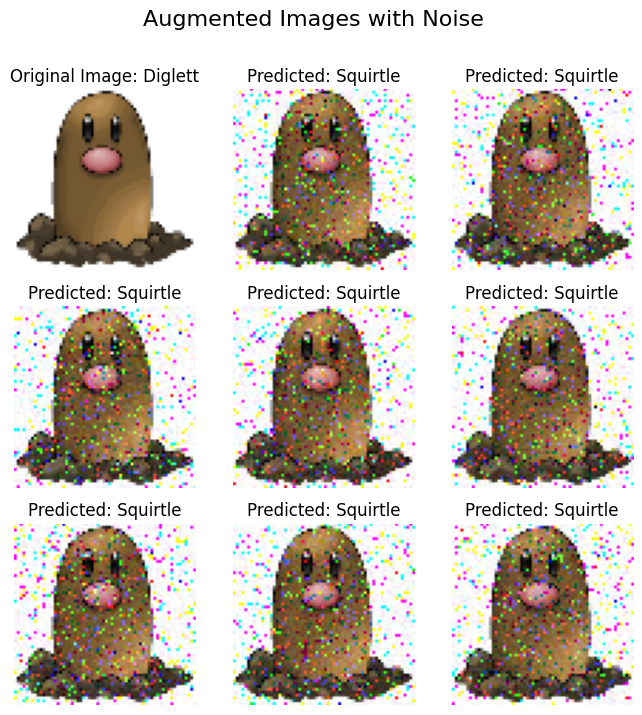

In [ ]:
# Plot the original image and 8 augmented images with noise
# Show your CNN model's predictions for each image (hopefully some correct and incorrect!)
if __name__ == '__main__':
    plt.figure(figsize=(8, 8))
    img_path = os.path.join(image_dir, 'Diglett_0.png')
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    plt.subplot(3, 3, 1)
    plt.title('Original Image: Diglett')
    plt.imshow(img)
    plt.axis('off')
    for i in range(1, 9):
        plt.subplot(3, 3, i+1)
        noisy_img = add_noise(img)
        pred = cnn_model.predict(np.array([noisy_img]), verbose=0)
        plt.title(f'Predicted: {pokemon_label_list[np.argmax(pred)]}')
        plt.imshow(noisy_img)
        plt.axis('off')
    plt.suptitle('Augmented Images with Noise', fontsize=16)
    plt.show()

To denoise the image, we can build a **convolutional auto-encoder**. You can think of it as a special form of neural network that can be implemented using CNNs. It consists of two main parts:
- Encoder: This part compresses the input data into a lower-dimensional representation (also called a "latent space"). Think of it as summarizing the input information.
- Decoder: This part takes the compressed representation and attempts to reconstruct the original input, aiming to make the output as similar as possible to the input.

The encoder functions similarly to the combined `Conv2D` and `MaxPooling2D` layers in your trained CNN model. In previous tasks, your model flattened the encoder output and passed it to the dense and dropout layers with 10 output neurons, making it a classification model. Now, we will replace the dense layers with a decoder that upsamples the encoder output and uses convolutional layers to generate the image from upsampled the encoder output.

Check out this [introduction video](https://www.youtube.com/watch?v=qiUEgSCyY5o) by IBM to learn more about how auto-encoders work.

<img src="https://framerusercontent.com/images/0nBS6F387hiWsQcKmx1k81iN8U.png" alt="captcha" height="400">

First, we will prepare the data:
- `X` stores each image as a numpy array with the shape (IMG_SIZE, IMG_SIZE, 3).
- `X_noisy` stores the noisy version of each image in `X`, having the same shape as `X`.

Next, we will prepare the training and testing datasets:
- `X_train`, `X_test`: The training and testing data for the model input — the noisy images.
- `y_train`, `y_test`: The training and testing data for the model output — the original images.

In [89]:
if __name__ == '__main__':
    files = [f for f in os.listdir(image_dir)]
    X_noisy = []
    X = []
    for f in files:
        pokemon_name = f.split('_', 1)[0]
        if pokemon_name in pokemon_label_list and "aug" not in f:
            img_path = os.path.join(image_dir, f)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # resize to 64x64
            img = img / 255.0  # normalize to [0, 1]
            for i in range(5):  # augment each image 5 times
                noisy_img = add_noise(img)
                X_noisy.append(noisy_img)
                X.append(img)
    X_noisy = np.array(X_noisy)
    X = np.array(X)
    X_train, X_test, y_train, y_test = train_test_split(X_noisy, X, test_size=0.2, random_state=42)
    print(f"shape of X_train: {X_train.shape}")
    print(f"shape of y_train: {y_train.shape}")
    print(f"shape of X_test: {X_test.shape}")
    print(f"shape of y_test: {y_test.shape}")

shape of X_train: (3760, 64, 64, 3)
shape of y_train: (3760, 64, 64, 3)
shape of X_test: (940, 64, 64, 3)
shape of y_test: (940, 64, 64, 3)


Now, it is time to build and train your auto-encoder architecture, which contains two parts: the encoder and the decoder.


The encoder is similar to the first parts of your classification model. You can use the following 3 layers:
1. `Conv2D`: You are free to explore kernel configurations, activations, etc. [Doc.](https://keras.io/api/layers/convolution_layers/convolution2d/)
2. `MaxPooling2D`: You are free to explore the pooling size, stride, etc. [Doc.](https://keras.io/api/layers/pooling_layers/max_pooling2d/)


Then build the decoder, which is like the opposite version of encoder. You can use the following 2 layers:
1. `Conv2D`: You are free to explore kernel configurations, activations, etc. [Doc.](https://keras.io/api/layers/convolution_layers/convolution2d/)
2. `UpSampling2D`: You are free to explore the configurations. [Doc.](https://keras.io/api/layers/reshaping_layers/up_sampling2d/)


Your model should contain at least one layer from each of the mentioned types. Optionally, you can add some `Dense` or `Dropout` layers. The last layer should be a `Conv2D` that output the same input image size, representing the denoised image. Again, using layer types not listed here is strictly prohibited.

After building your desired architecture, you need to compile the model with following parameters:
1. `optimizer`: An algorithm which updates the model's weight during training to minimize the loss function. You are free to explore different optimizers but we recommend `adam`.
2. `loss`: A mathematical function which measures how far the denoised images are from original images. You are free to choose your own, but we recommend `mse`.
3. metrics: evaluation measures used to assess the model performance. You are free to choose your own, but we recommend `mae`.

**Hint:** The model in our solution uses approximately 600,000 trainable parameters. We suggest you keep the number of trainable parameters under 1,000,000 for efficient training and to avoid overfitting.


**Task 6**: Complete the `get_auto_encoder()` function

In [91]:
def get_auto_encoder():
    # TODO (Task 6): Complete the convolutional auto-encoder architecture based on the instructions
    
    model = Sequential()

    # ENCODER 
    # Compresses image down to small latent feature map
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))  # Final compressed feature map

    #  DECODER (Allowed: Conv2D, UpSampling2D) 
    # Reconstructs image BACK to original 64x64 size
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))  # Opposite of MaxPooling

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(UpSampling2D((2, 2)))

    # FINAL LAYER: Output = same as input (64x64x3) → for denoising
    model.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same'))
    
    model.compile(
        optimizer='adam',   # follow whatever u said
        loss='mse',            
        metrics=['mae']        
    )

    return model # Replace None with the model


if __name__ == '__main__':
    auto_encoder = get_auto_encoder()
    auto_encoder.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
    auto_encoder.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_18 (UpSampling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_19 (UpSampling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_20 (UpSampling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

It is now time to train the auto-encoder you built in the previous tasks. You are free to explore different configurations of parameters. However, keep in mind that increasing the number of training epochs requires more computational resources and time, and it does not necessarily indicate better model performance due to the potential for overfitting.

**Task 7**: Train your auto-encoder.

In [92]:
if __name__ == '__main__':
    # TODO (Task 7): Train the auto-encoder. Feel free to change the codes below
    # history = auto_encoder.fit(x=X_train, y=X_train, epochs=20, batch_size=32, validation_data=(X_test, X_test))
    history = auto_encoder.fit(
    x=X_train,       # 输入：噪音图
    y=y_train,       # 目标：干净图  🎯🎯🎯 正确！
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - loss: 0.0507 - mae: 0.1668 - val_loss: 0.0290 - val_mae: 0.1150
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 207ms/step - loss: 0.0249 - mae: 0.1046 - val_loss: 0.0215 - val_mae: 0.0945
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 25s 210ms/step - loss: 0.0214 - mae: 0.0933 - val_loss: 0.0197 - val_mae: 0.0883
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 225ms/step - loss: 0.0193 - mae: 0.0861 - val_loss: 0.0186 - val_mae: 0.0826
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 257ms/step - loss: 0.0183 - mae: 0.0828 - val_loss: 0.0175 - val_mae: 0.0796
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - loss: 0.0175 - mae: 0.0799 - val_loss: 0.0177 - val_mae: 0.0785
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 240ms/step - loss: 0.0170 - mae: 0.0782 - val_loss: 0.0165 - val_mae: 0.0762
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 26s 224ms/step - loss: 0.0163 - mae: 0.0759 - val_loss: 0.0235 - val_mae: 0.0892
Epoch 9/20
118/118 ━━━━━━━━━━━━━

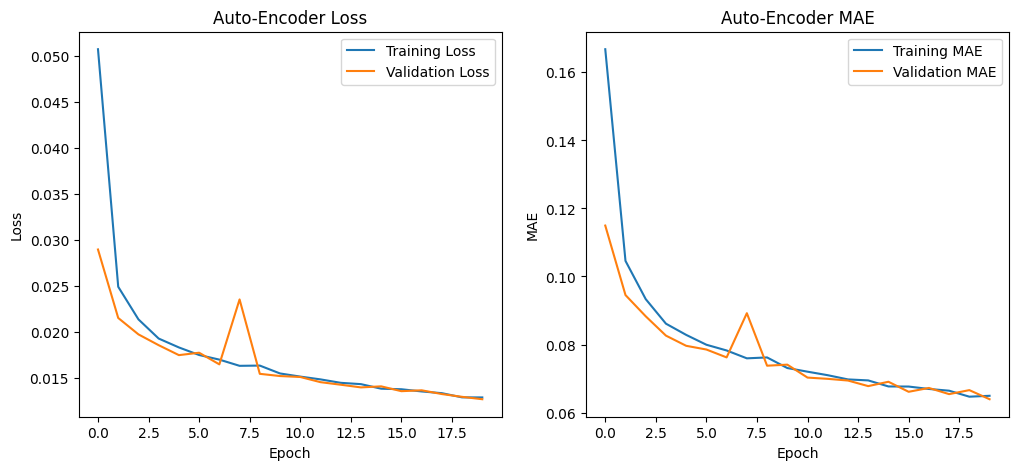

In [96]:
# Plot your auto-encoder's training and validation loss curves
if __name__ == '__main__':
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Auto-Encoder Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Auto-Encoder MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.show()

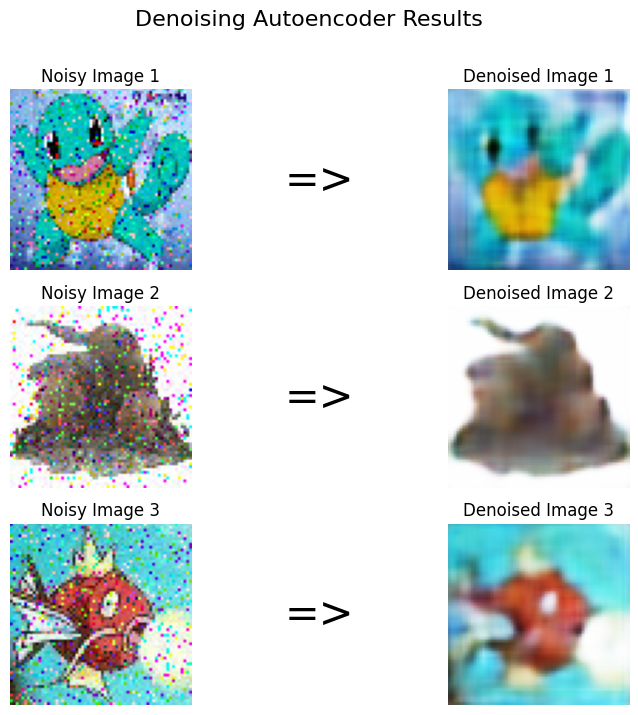

In [97]:
# Visualize the denoising results
# You should see that the denoised images are much clearer than the noisy images
# Yet, remember that the denoised images may be blurry due to the nature of auto-encoders
if __name__ == '__main__':
    plt.figure(figsize=(8, 8))
    noisy_img = random.sample(list(X_noisy), 3)
    for i in range(0, 3):
        plt.subplot(3, 3, i*3 + 1)
        plt.title(f"Noisy Image {i+1}")
        plt.imshow(noisy_img[i])
        plt.axis('off')
        plt.subplot(3, 3, i*3 + 2)
        plt.text(0.5, 0.5, "=>", fontsize=30, ha='center', va='center')
        plt.axis('off')
        plt.subplot(3, 3, i*3 + 3)
        denoised_img = auto_encoder.predict(np.array([noisy_img[i]]), verbose=0)[0]
        plt.title(f'Denoised Image {i+1}')
        plt.imshow(denoised_img)
        plt.axis('off')
    plt.suptitle('Denoising Autoencoder Results', fontsize=16)
    plt.show()

PSNR (Peak Signal-to-Noise Ratio) is a common objective metric used to evaluate the quality of a denoised image relative to its original 'clean' version. A higher PSNR indicates that the denoised image is more similar to the original. We will use this metric to measure the improvement achieved by our auto-encoder:

In [98]:
# Compute the PSNR between the original and denoised images
if __name__ == '__main__':
    def compute_psnr(original, denoised):
        mse = np.mean((original - denoised) ** 2)
        if mse == 0: # most likely it won't happen
            return 100
        psnr = 10 * np.log10(1.0 / np.sqrt(mse))
        return psnr
    psnr_denoised = []
    psnr_noisy = []
    sample_X = random.sample(list(X), 100)
    for i in range(len(sample_X)):
        noisy_img = add_noise(sample_X[i])
        denoised_img = auto_encoder.predict(np.array([noisy_img]), verbose=0)[0]
        psnr_denoised.append(compute_psnr(sample_X[i], denoised_img))
        psnr_noisy.append(compute_psnr(sample_X[i], noisy_img))
    average_noisy_psnr = np.mean(psnr_noisy)
    average_psnr = np.mean(psnr_denoised)
    print(f"Average PSNR between original and denoised images: {average_psnr:.2f} dB")
    print(f"Average PSNR between original and noisy images: {average_noisy_psnr:.2f} dB")
    print(f"PSNR Improvement (%) : {(average_psnr - average_noisy_psnr) / average_noisy_psnr * 100:.2f} %")

Average PSNR between original and denoised images: 9.84 dB
Average PSNR between original and noisy images: 7.42 dB
PSNR Improvement (%) : 32.56 %


Once you are satisfied with the model's performance, you can run the cell below to save your CNN model. You will need to download this saved model to your local machine for submission.

Additionally, to show that the model is trained by you, ensure that your submitted model has the same structure as the model returned from Task 6.

In [102]:
if __name__ == '__main__':
  auto_encoder.save("auto_encoder.keras")

*OPTIONAL*

As an alternative to evaluate your auto-encoder, you can feed your denoised images into your CNN to observe the improvement in accuracy. Since using accuracy improvement as a grading metric can be inconsistent (for instance, if your CNN already performs well on noisy images), we have left this part as an optional exercise for interested students. The data has been loaded for you. Try to implement the code to compare the model's performance on noisy and denoised sets.

In [101]:
if __name__ == '__main__':
    # Load the dataset again to get the original images and labels for testing the CNN model on noisy images
    pokemon_label_list = ['Bulbasaur', 'Charmander', 'Diglett', 'Dugtrio', 'Jigglypuff', 'Magikarp', 'Pikachu', 'Raichu', 'Squirtle', 'Starmie']
    files = [f for f in os.listdir(image_dir)]
    X = []
    noisy_X = []
    y = []
    for f in files:
        pokemon_name = f.split('_', 1)[0]
        if pokemon_name in pokemon_label_list:
            img_path = os.path.join(image_dir, f)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # resize to 64x64
            img = img / 255.0  # normalize to [0, 1]
            X.append(img)
            noisy_X.append(add_noise(img))
            y.append(pokemon_label_list.index(pokemon_name))
    X = np.array(X)
    noisy_X = np.array(noisy_X)
    y = np.array(y)
    y = y.reshape(-1, 1)
    
    # Load the trained CNN model and the auto-encoder model
    from keras.models import load_model
    cnn_model = load_model('cnn_model.keras')
    autoencoder_model = load_model('auto_encoder_model.keras')

    # Test the CNN model on the noisy images and the denoised images. 
    # Implement the code to compute the accuracy of the CNN model on both noisy and denoised images and print the results.
    # Hint: You can use the same code as before to compute the accuracy, but remember to use the noisy_X for noisy images and autoencoder_model.predict(noisy_X) for denoised images.
    

ValueError: File not found: filepath=auto_encoder_model.keras. Please ensure the file is an accessible `.keras` zip file.

Disclaimer: Please do not use AI models to bypass CAPTCHA checks in real-world scenarios, as it is unethical :P